# Predicción por Regresión

1) Cargar los datos

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import data_report

ruta = os.getcwd()
df = pd.read_csv(ruta + "\\precio_vivienda.csv", index_col=0)
df.reset_index(inplace=True)
df

,precio,m2,antiguedad,salas,dormitorios,renta_zona,poblacion_zona
0,317710.2,243.18,5.68,7.0,4.0,79545.46,23086.80
1,451767.3,234.83,6.00,7.0,3.0,79248.64,40173.07
2,317696.4,288.28,5.87,9.0,5.0,61287.07,36882.16
3,378185.1,200.50,7.19,6.0,3.0,63345.24,34310.24
4,189282.9,268.08,5.04,8.0,4.0,59982.20,26354.11
...,...,...,...,...,...,...,...
4995,318058.2,217.02,7.83,6.0,3.0,60567.94,22837.36
4996,444785.4,230.20,7.00,7.0,4.0,78491.28,25616.12
4997,309219.0,177.05,7.25,5.0,2.0,63390.69,33266.15
4998,359597.1,246.81,5.53,7.0,5.0,68001.33,42625.62


In [2]:
data_report(df)

Información general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   precio          5000 non-null   float64
 1   m2              5000 non-null   float64
 2   antiguedad      5000 non-null   float64
 3   salas           5000 non-null   float64
 4   dormitorios     5000 non-null   float64
 5   renta_zona      5000 non-null   float64
 6   poblacion_zona  5000 non-null   float64
dtypes: float64(7)
memory usage: 273.6 KB
None


Resumen estadístico:

              precio           m2   antiguedad        salas  dormitorios  \
count    5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean   369621.797640   242.534648     5.977278     6.988400     3.741200   
std    105935.287688    30.175065     0.991437     1.044262     1.228057   
min      4781.700000   129.990000     2.640000     3.000000     2.000000   
25%    299273.17

## Separate independent and dependent variables

In [3]:
variable_dependiente = 'precio'
y ='precio'

variables_independientes = df.columns[df.columns!=variable_dependiente]
x = df.columns[df.columns!=variable_dependiente]

variables_independientes

Index(['m2', 'antiguedad', 'salas', 'dormitorios', 'renta_zona',
       'poblacion_zona'],
      dtype='object')

In [4]:
x = df[variables_independientes]
y = df[variable_dependiente]

x

,m2,antiguedad,salas,dormitorios,renta_zona,poblacion_zona
0,243.18,5.68,7.0,4.0,79545.46,23086.80
1,234.83,6.00,7.0,3.0,79248.64,40173.07
2,288.28,5.87,9.0,5.0,61287.07,36882.16
3,200.50,7.19,6.0,3.0,63345.24,34310.24
4,268.08,5.04,8.0,4.0,59982.20,26354.11
...,...,...,...,...,...,...
4995,217.02,7.83,6.0,3.0,60567.94,22837.36
4996,230.20,7.00,7.0,4.0,78491.28,25616.12
4997,177.05,7.25,5.0,2.0,63390.69,33266.15
4998,246.81,5.53,7.0,5.0,68001.33,42625.62


In [5]:
y

0       317710.2
1       451767.3
2       317696.4
3       378185.1
4       189282.9
          ...   
4995    318058.2
4996    444785.4
4997    309219.0
4998    359597.1
4999    389685.0
Name: precio, Length: 5000, dtype: float64

<Figure size 1000x800 with 0 Axes>

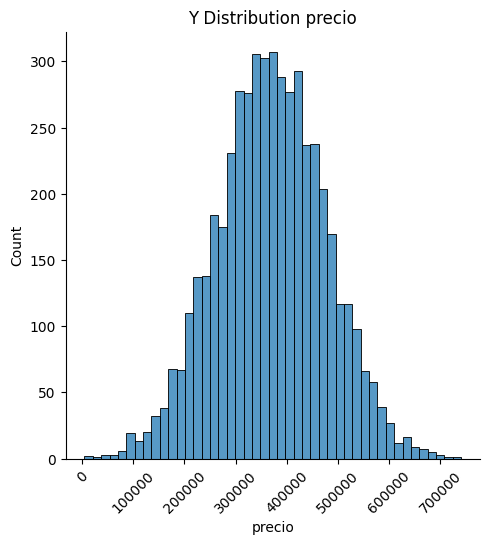

In [6]:
plt.figure(figsize=(10,8))
sns.displot(y)
plt.title('Y Distribution ' + variable_dependiente)
plt.xticks(rotation=45)
plt.show()

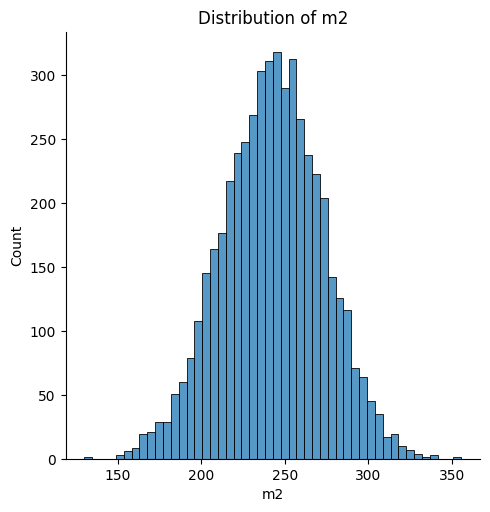

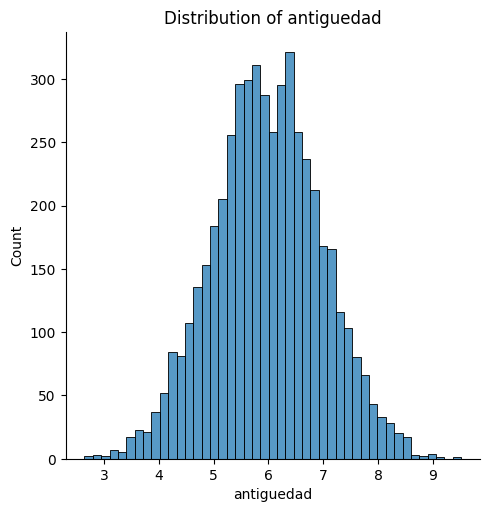

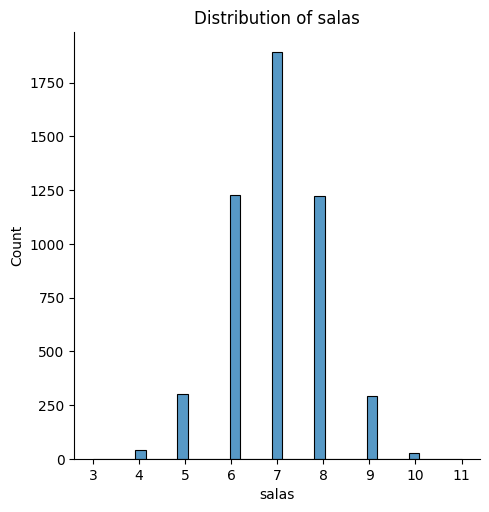

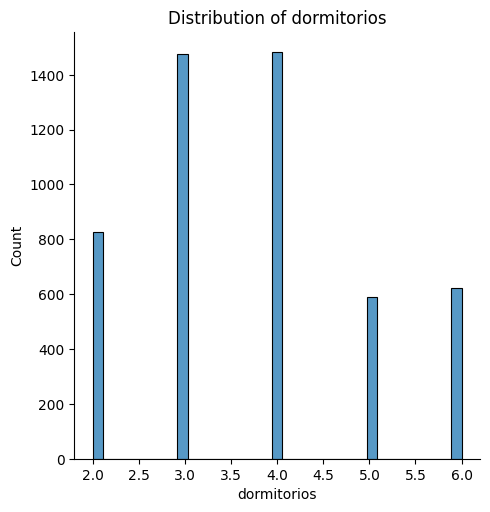

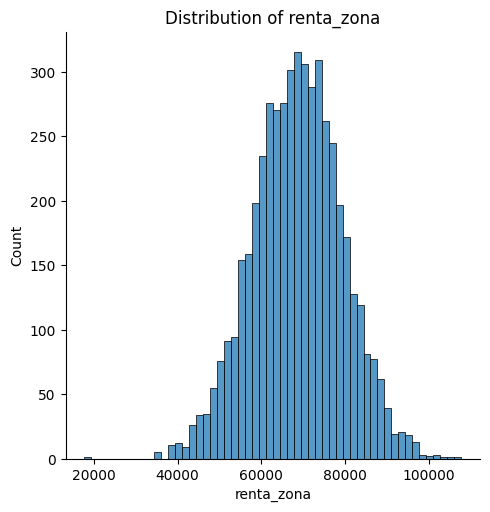

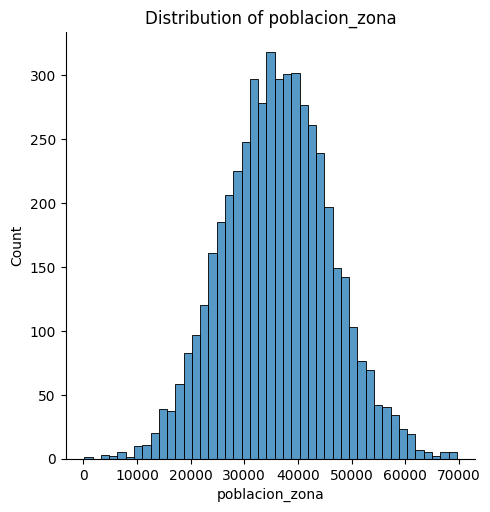

In [7]:
for i in variables_independientes:

    sns.displot(x[i])
    plt.title(f'Distribution of {i}')
    plt.show()

### Change the type of dormitorios and salas

In [8]:
df[['dormitorios','salas']] = df[['dormitorios','salas']].astype('int8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   precio          5000 non-null   float64
 1   m2              5000 non-null   float64
 2   antiguedad      5000 non-null   float64
 3   salas           5000 non-null   int8   
 4   dormitorios     5000 non-null   int8   
 5   renta_zona      5000 non-null   float64
 6   poblacion_zona  5000 non-null   float64
dtypes: float64(5), int8(2)
memory usage: 205.2 KB


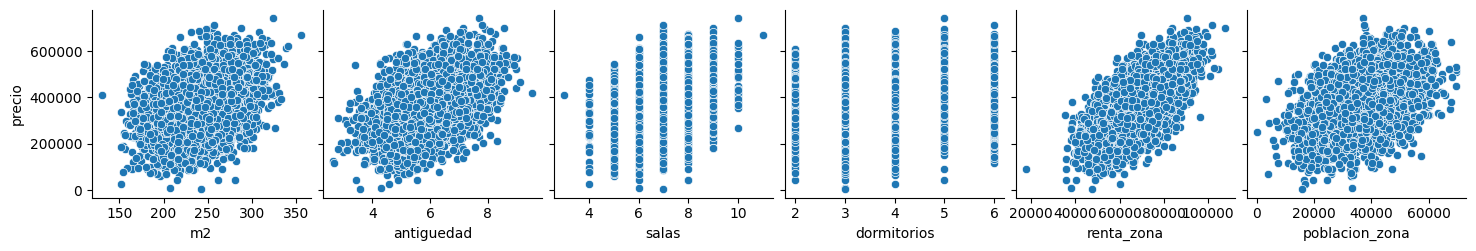

In [9]:
sns.pairplot(data=df, x_vars= variables_independientes, y_vars= variable_dependiente)
plt.show()

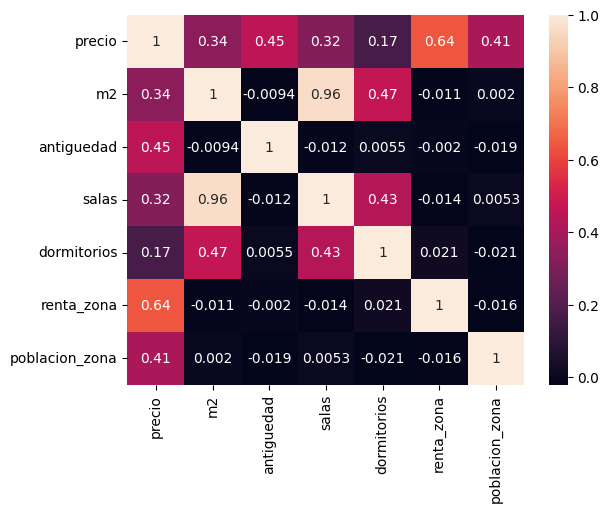

In [10]:
### Comprobete correlation
sns.heatmap(df.corr(), annot=True)
plt.show()

In [11]:
#After to see the relation between variables I'm going to delete all those that don't have correlation
def delete_var_corr(X,y,umbral):
    col_corr = []
    col_names = []
    filas_names = []
    
    matriz_corr = X.corr()

    for i in range(len(matriz_corr.columns)):
        for j in range(i):
            if (matriz_corr.iloc[i,j] >= umbral) and (matriz_corr.columns[j] not in col_corr):

                col_names.append(matriz_corr.columns[i])
                filas_names.append(matriz_corr.index[j])
                col_corr.append(matriz_corr.columns[i])

    corr_col = [np.abs(np.corrcoef(X[col],y)[0,1]) for col in col_names]
    corr_fila = [np.abs(np.corrcoef(X[fila],y)[0,1]) for fila in filas_names]    

    Z = pd.DataFrame({
        'col_names':col_names,
        'filas_names': filas_names,
        'col_corr':col_corr,
        'corr_variable_dependient_col':corr_col,
        'corr_variable_dependiente_fila':corr_fila
    })

    Z['elimina'] = np.where(Z['corr_variable_dependient_col']<Z['corr_variable_dependiente_fila'],Z['col_names'],Z['filas_names'])

    return Z
delete_var_corr = delete_var_corr(x,y,0.95)
delete_var_corr

,col_names,filas_names,col_corr,corr_variable_dependient_col,corr_variable_dependiente_fila,elimina
0,salas,m2,salas,0.321108,0.335664,salas


In [12]:
#x.drop(axis=1, columns=delete_var_corr['elimina'], inplace=True)

In [21]:
from sklearn.feature_selection import VarianceThreshold

#We set the threshold to remove columns where 99% of the values ​​are the same
vt = VarianceThreshold(threshold=0.01)
vt.fit(x)

#We identified the columns with low variance
columnas_bajavar =x.columns[vt.get_support() == False]

#We remove the columns with low variance
#X.drop(columns=columnas_bajavar, inplace=True)

#We print the number of columns deleted and their names
print(len(columnas_bajavar),' Low variance features were removed:\n', columnas_bajavar.to_list())

0  Low variance features were removed:
 []


In [ ]:
#Separate the variables
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test,y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=34)


In [ ]:
#Standardize data
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[0.50861563, 0.64252696, 0.42857143, 1.        , 0.35395048,
        0.67875206],
       [0.49167809, 0.43451464, 0.42857143, 0.5       , 0.64645562,
        0.7473063 ],
       [0.19796358, 0.51309707, 0.14285714, 0.25      , 0.59590377,
        0.75008877],
       ...,
       [0.38486391, 0.26656394, 0.42857143, 0.5       , 0.49873278,
        0.34810271],
       [0.08679264, 0.64714946, 0.14285714, 0.25      , 0.58740425,
        0.84408092],
       [0.37130409, 0.76117103, 0.28571429, 0.5       , 0.62577493,
        0.53779243]])

In [ ]:
#Separating the data many times
from sklearn.linear_model import LinearRegression

algoritmo = LinearRegression()
np.mean(-cross_val_score(algoritmo, x,y,cv=5,scoring='neg_root_mean_squared_error'))

30386.03386493725

In [ ]:
#Evaluation metrics
def RMSE(model,X,y):
    return round(np.sqrt(np.mean((y-model.predict(X))**2)),2)

def cross_validation(model,X,y):
    Kfold_rmse = cross_val_score(model,X,y,cv=4,scoring='neg_root_mean_squared_error')
    return round(-Kfold_rmse.mean(),2)

In [ ]:
#Import all models for evaluation
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

In [19]:
label_ = []
rmse_train = []
rmse_valida = []

def evaluar_regression(label,model,X,y,verbose=True,cv=True):
    model.fit(X,y)
    rmse = RMSE(model,X,y)
    cross = cross_validation(model,X,y)
    label_.append(label)
    rmse_train.append(rmse)
    
    if cv==True:
        rmse_valida.append(cross)
    else:
        rmse_valida.append(-1)
    
    if verbose==True:
        return pd.DataFrame({'Model':label_,
                             'RMSE Train':rmse_train,
                             'RMSE Cross validation':rmse_valida
                             }).sort_values('RMSE Cross validation')


In [20]:
evaluar_regression(
    label='LinearRegresion',
    model = LinearRegression(),
    X= X_train,
    y = y_train
)
evaluar_regression(
    label='Ridge',
    model = Ridge(),
    X= X_train,
    y = y_train
)
evaluar_regression(
    label='Lasso',
    model = Lasso(),
    X= X_train,
    y = y_train
)
evaluar_regression(
    label='ElasticNet',
    model = ElasticNet(),
    X= X_train,
    y = y_train
)
evaluar_regression(
    label='DecisionTreeRegressor',
    model = DecisionTreeRegressor(),
    X= X_train,
    y = y_train
)
evaluar_regression(
    label='KNeighborsRegressor',
    model = KNeighborsRegressor(),
    X= X_train,
    y = y_train
)

,Model,RMSE Train,RMSE Cross validation
2,Lasso,30016.24,30063.36
1,Ridge,30016.24,30063.45
0,LinearRegresion,30016.24,30063.46
3,ElasticNet,34327.12,34371.37
4,DecisionTreeRegressor,0.00,53875.06
5,KNeighborsRegressor,61315.27,75557.52
